# Mónica María Ramírez Mejía - A01797493

# Actividad 2 (abajo continúa la Actividad 4)

In [1]:
import os
import sys
os.environ["JAVA_HOME"] = r"C:\Users\monic\anaconda3\envs\env_pyspark\Library\lib\jvm"
os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["PYSPARK_SUBMIT_ARGS"] = "--conf spark.driver.host=127.0.0.1 --conf spark.driver.bindAddress=127.0.0.1 pyspark-shell"

In [2]:
import findspark
findspark.init()
from pyspark import SparkContext, SparkConf, SQLContext
from pyspark.sql import SparkSession

In [3]:
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Etapa2") \
    .getOrCreate()
spark

In [4]:
import sys
!{sys.executable} -m pip install matplotlib

In [5]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

In [6]:
df = spark.read.csv(
    r"C:\Users\monic\Desktop\2. Analisis de Datos\Taxi_Trips_-_2023.csv",
    header=True,
    sep = ",",
    inferSchema=True
)
df.show()

+--------------------+--------------------+--------------------+--------------------+------------+----------+-------------------+--------------------+---------------------+----------------------+-----+-----+-----+------+----------+------------+--------------------+------------------------+-------------------------+------------------------+-------------------------+--------------------------+--------------------------+
|             Trip ID|             Taxi ID|Trip Start Timestamp|  Trip End Timestamp|Trip Seconds|Trip Miles|Pickup Census Tract|Dropoff Census Tract|Pickup Community Area|Dropoff Community Area| Fare| Tips|Tolls|Extras|Trip Total|Payment Type|             Company|Pickup Centroid Latitude|Pickup Centroid Longitude|Pickup Centroid Location|Dropoff Centroid Latitude|Dropoff Centroid Longitude|Dropoff Centroid  Location|
+--------------------+--------------------+--------------------+--------------------+------------+----------+-------------------+--------------------+------

In [7]:
df.printSchema()

root
 |-- Trip ID: string (nullable = true)
 |-- Taxi ID: string (nullable = true)
 |-- Trip Start Timestamp: string (nullable = true)
 |-- Trip End Timestamp: string (nullable = true)
 |-- Trip Seconds: integer (nullable = true)
 |-- Trip Miles: double (nullable = true)
 |-- Pickup Census Tract: long (nullable = true)
 |-- Dropoff Census Tract: long (nullable = true)
 |-- Pickup Community Area: integer (nullable = true)
 |-- Dropoff Community Area: integer (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Tips: double (nullable = true)
 |-- Tolls: double (nullable = true)
 |-- Extras: double (nullable = true)
 |-- Trip Total: double (nullable = true)
 |-- Payment Type: string (nullable = true)
 |-- Company: string (nullable = true)
 |-- Pickup Centroid Latitude: double (nullable = true)
 |-- Pickup Centroid Longitude: double (nullable = true)
 |-- Pickup Centroid Location: string (nullable = true)
 |-- Dropoff Centroid Latitude: double (nullable = true)
 |-- Dropoff Centroid 

In [8]:
df.columns

['Trip ID',
 'Taxi ID',
 'Trip Start Timestamp',
 'Trip End Timestamp',
 'Trip Seconds',
 'Trip Miles',
 'Pickup Census Tract',
 'Dropoff Census Tract',
 'Pickup Community Area',
 'Dropoff Community Area',
 'Fare',
 'Tips',
 'Tolls',
 'Extras',
 'Trip Total',
 'Payment Type',
 'Company',
 'Pickup Centroid Latitude',
 'Pickup Centroid Longitude',
 'Pickup Centroid Location',
 'Dropoff Centroid Latitude',
 'Dropoff Centroid Longitude',
 'Dropoff Centroid  Location']

In [9]:
#numero de columnas
len(df.columns)

23

In [10]:
#numero de registros
df.count()

3783730

In [11]:
#tipo de datos
df.dtypes

[('Trip ID', 'string'),
 ('Taxi ID', 'string'),
 ('Trip Start Timestamp', 'string'),
 ('Trip End Timestamp', 'string'),
 ('Trip Seconds', 'int'),
 ('Trip Miles', 'double'),
 ('Pickup Census Tract', 'bigint'),
 ('Dropoff Census Tract', 'bigint'),
 ('Pickup Community Area', 'int'),
 ('Dropoff Community Area', 'int'),
 ('Fare', 'double'),
 ('Tips', 'double'),
 ('Tolls', 'double'),
 ('Extras', 'double'),
 ('Trip Total', 'double'),
 ('Payment Type', 'string'),
 ('Company', 'string'),
 ('Pickup Centroid Latitude', 'double'),
 ('Pickup Centroid Longitude', 'double'),
 ('Pickup Centroid Location', 'string'),
 ('Dropoff Centroid Latitude', 'double'),
 ('Dropoff Centroid Longitude', 'double'),
 ('Dropoff Centroid  Location', 'string')]

In [12]:
#eliminar variables con nulos
df = df.drop('Pickup Census Tract', 'Dropoff Census Tract')

In [13]:
print('Registros en df:', df.count())
print('Columnas en df:', len(df.columns))

Registros en df: 3783730
Columnas en df: 21


In [14]:
variables_numericas = [
    'Trip Seconds',
    'Trip Miles',
    'Trip Total']
variables_categoricas = [
    'Payment Type',
    'Company',
    'Pickup Community Area',
    'Dropoff Community Area']

In [15]:
df.select(variables_numericas).describe().show(truncate=False)

+-------+------------------+----------------+------------------+
|summary|Trip Seconds      |Trip Miles      |Trip Total        |
+-------+------------------+----------------+------------------+
|count  |3783012           |3783717         |3778327           |
|mean   |1235.3278387697421|6.47123319476644|27.371134848836093|
|stddev |1736.5661018295136|7.59331044121222|37.03373571024754 |
|min    |0                 |0.0             |0.0               |
|max    |86340             |945.4           |9999.75           |
+-------+------------------+----------------+------------------+



In [16]:
for variable in variables_categoricas:
    total = df.count()

    df.groupBy(variable) \
      .agg(F.count('*').alias('Frecuencia')) \
      .withColumn('Porcentaje', F.round(F.col('Frecuencia') / total * 100, 2)) \
      .orderBy(F.desc('Frecuencia')) \
      .show(20, truncate=False)

+------------+----------+----------+
|Payment Type|Frecuencia|Porcentaje|
+------------+----------+----------+
|Credit Card |1520430   |40.18     |
|Cash        |1124909   |29.73     |
|Mobile      |580667    |15.35     |
|Prcard      |379855    |10.04     |
|Unknown     |175157    |4.63      |
|No Charge   |1588      |0.04      |
|Dispute     |1124      |0.03      |
+------------+----------+----------+

+------------------------------------+----------+----------+
|Company                             |Frecuencia|Porcentaje|
+------------------------------------+----------+----------+
|Taxi Affiliation Services           |728012    |19.24     |
|Flash Cab                           |726379    |19.2      |
|Sun Taxi                            |415999    |10.99     |
|City Service                        |390815    |10.33     |
|Taxicab Insurance Agency Llc        |347161    |9.18      |
|Chicago Independents                |221781    |5.86      |
|5 Star Taxi                         |17511

In [17]:
#Nulos en las variables de particion
N = df.count()
nulos_payment = df.filter(F.col('Payment Type').isNull()).count()
nulos_miles = df.filter(F.col('Trip Miles').isNull()).count()
nulos_ambos = df.filter(
    F.col('Payment Type').isNull() | F.col('Trip Miles').isNull()
).count()
porc_payment = nulos_payment / N * 100
porc_miles = nulos_miles / N * 100
porc_ambos = nulos_ambos / N * 100
print(f'Total de registros: {N:,}')
print(f'Nulos en Payment Type : {nulos_payment:,} ({porc_payment:.4f}%)')
print(f'Nulos en Trip Miles   : {nulos_miles:,} ({porc_miles:.4f}%)')

Total de registros: 3,783,730
Nulos en Payment Type : 0 (0.0000%)
Nulos en Trip Miles   : 13 (0.0003%)


In [18]:
#Eliminamos nulos de trip miles (tienen una baja representacion y no afecta nuestro analisis)
df = df.filter(F.col('Trip Miles').isNotNull())

In [19]:
#Calculo de probabilidades
# Total de registros
N = df.count()
print(f"N total = {N:,}")

N total = 3,783,717


In [20]:
#PAYMENT TYPE
n_electronico = df.filter(
    F.col("Payment Type").isin(["Credit Card", "Mobile", "Prcard"])).count()
n_otro = N-n_electronico
P_a = n_electronico/N     # Probabilidad de electronico
P_b = n_otro/N            # Probabilidad de otro
print('P electrónico:', P_a)
print('P otro:', P_b)

P electrónico: 0.6556906872263438
P otro: 0.3443093127736562


In [21]:
#TRIP MILES
n_corto = df.filter(F.col("Trip Miles") <= 6.47).count()
n_largo = N-n_corto
P_c = n_corto/N   # Probabilidad viaje corto
P_d = n_largo/N   # Probabilidad viaje largo
print('P viaje corto:', P_c)
print('P viaje largo:', P_d)

P viaje corto: 0.6225071801088717
P viaje largo: 0.3774928198911282


In [22]:
#Combinaciones (probabilidad estimada)
P1 = P_a * P_c
P2 = P_a * P_d
P3 = P_b * P_c
P4 = P_b * P_d
print('P1:', P1)
print('P2:', P2)
print('P3:', P3)
print('P4:', P4)

P1: 0.4081721607289195
P2: 0.24751852649742428
P3: 0.21433501937995222
P4: 0.12997429339370392


In [23]:
#probabilidad real
p1 = df.filter(
    (F.col('Payment Type').isin(['Credit Card', 'Mobile', 'Prcard'])) &
    (F.col('Trip Miles') <= 6.47))
p2 = df.filter(
    (F.col('Payment Type').isin(['Credit Card', 'Mobile', 'Prcard'])) &
    (F.col('Trip Miles') > 6.47))
p3 = df.filter(
    (~F.col('Payment Type').isin(['Credit Card', 'Mobile', 'Prcard'])) &
    (F.col('Trip Miles') <= 6.47))
p4 = df.filter(
    (~F.col('Payment Type').isin(['Credit Card', 'Mobile', 'Prcard'])) &
    (F.col('Trip Miles') > 6.47))
print(f'Pago electrónico y viaje corto (p1): {p1.count():,}  |  P_real: {p1.count()/N:.4f}')
print(f'Pago electrónico y viaje largo (p2): {p2.count():,}  |  P_real: {p2.count()/N:.4f}')
print(f'Otro método de pago y viaje corto (p3): {p3.count():,}  |  P_real: {p3.count()/N:.4f}')
print(f'Otro método de pago y viaje largo (p4): {p4.count():,}  |  P_real: {p4.count()/N:.4f}')

Pago electrónico y viaje corto (p1): 1,382,155  |  P_real: 0.3653
Pago electrónico y viaje largo (p2): 1,098,793  |  P_real: 0.2904
Otro método de pago y viaje corto (p3): 973,236  |  P_real: 0.2572
Otro método de pago y viaje largo (p4): 329,533  |  P_real: 0.0871


In [24]:
p1.count() + p2.count() + p3.count() + p4.count()

3783717

In [25]:
N

3783717

In [26]:
# Submuestra
for nombre, part in [("p1", p1), ("p2", p2), ("p3", p3), ("p4", p4)]:
    m = part.sample(withReplacement=False, fraction=0.005, seed=42)
    print(f"Muestra {nombre}: {m.count()} registros")
    m.select("Payment Type", "Trip Miles", "Trip Total").show(3)

Muestra p1: 6927 registros
+------------+----------+----------+
|Payment Type|Trip Miles|Trip Total|
+------------+----------+----------+
|      Mobile|      1.36|     13.67|
|      Mobile|      4.45|     19.63|
|      Mobile|      0.26|     50.63|
+------------+----------+----------+
only showing top 3 rows
Muestra p2: 5518 registros
+------------+----------+----------+
|Payment Type|Trip Miles|Trip Total|
+------------+----------+----------+
| Credit Card|      6.84|      25.0|
| Credit Card|     15.31|      50.6|
| Credit Card|      12.0|     42.25|
+------------+----------+----------+
only showing top 3 rows
Muestra p3: 4873 registros
+------------+----------+----------+
|Payment Type|Trip Miles|Trip Total|
+------------+----------+----------+
|        Cash|       0.0|      10.0|
|        Cash|       0.0|      3.25|
|        Cash|       1.6|     103.0|
+------------+----------+----------+
only showing top 3 rows
Muestra p4: 1609 registros
+------------+----------+----------+
|Payme

In [27]:
#muestreo
muestra_p1 = p1.sample(withReplacement=False, fraction=0.05, seed=42)
muestra_p2 = p2.sample(withReplacement=False, fraction=0.05, seed=42)
muestra_p3 = p3.sample(withReplacement=False, fraction=0.05, seed=42)
muestra_p4 = p4.sample(withReplacement=False, fraction=0.05, seed=42)

M = muestra_p1.union(muestra_p2).union(muestra_p3).union(muestra_p4)

n_m1 = muestra_p1.count()
n_m2 = muestra_p2.count()
n_m3 = muestra_p3.count()
n_m4 = muestra_p4.count()
n_M = M.count()

print(f'muestra_p1: {n_m1:,}')
print(f'muestra_p2: {n_m2:,}')
print(f'muestra_p3: {n_m3:,}')
print(f'muestra_p4: {n_m4:,}')
print(f'\nTamaño total de M: {n_M:,} registros')

M.select('Payment Type', 'Trip Miles', 'Trip Total').show(5)

muestra_p1: 69,194
muestra_p2: 55,161
muestra_p3: 48,869
muestra_p4: 16,519

Tamaño total de M: 189,743 registros
+------------+----------+----------+
|Payment Type|Trip Miles|Trip Total|
+------------+----------+----------+
|      Mobile|      2.27|     13.67|
|      Mobile|      4.75|     24.08|
| Credit Card|      0.03|      45.5|
|      Mobile|      4.45|     17.73|
|      Mobile|      1.55|      11.0|
+------------+----------+----------+
only showing top 5 rows


#######################################################################################################################

# Actividad 4 - Aplicar algoritmos de aprendizaje no supervisado con PySpark

### Aprendizaje no supervisado
El aprendizaje no supervisado es una tecnica de machine learning que permite analizar datos sin tener una variable objetivo pre-definida. Tiene el proposito de encontrar patrones, relaciones o grupos dentro de la población. Se diferencia del aprendizaje supervisado porque el algoritmo no recibe respuestas correctas durante el entrenamiento, sino que identifica similitudes entre las observaciones para organizarlas en grupos con caracteristicas similares.

Algunos modelos de aprendizaje no supervisado son:
* K-Means: agrupa observaciones similares en un numero determinado de clusters.
* DBSCAN: forma grupos segun la densidad de los datos y permite identificar valores atipicos.
* GMM: asigna probabilidades de pertenencia a diferentes grupos.
* Clustering jerarquico: construye una estructura de grupos organizada en niveles.
* PCA: reduce la cantidad de variables mientras conserva la información.

PySpark cuenta con la librería MLlib, en la cual existen diversos algoritmos de aprendizaje no supervisado que se pueden aplicar a grandes volúmenes de datos. Entre ellos se encuentran: K-Means, Bisecting K-Means, GMM, LDA y Power Iteration Clustering.

En este proyecto buscaremos identificar grupos de viajes con caracteristicas similares dentro del conjunto de datos. Se utilizan variables como la distancia recorrida, duración del viaje, tarifa, propinas, método de pago, etc. Antes de construir el modelo fue necesario preparar los datos, eliminar registros con valores nulos y transformar las variables categoricas para que pudieran ser usadas por el algoritmo.

Se seleccionó el modelo "K-Means" debido a su simplicidad, eficiencia y facilidad de interpretacion. Este algoritmo permite segmentar los viajes en distintos clusters según sus caracteristicas.

### Transformación de variables
Se transformaron las variables categóricas mediante StringIndexer y OneHotEncoder para que pudieran ser utilizadas por el algoritmo K-Means. Posteriormente, se usó VectorAssembler para integrar todas las variables en una única columna de caracteristicas y StandardScaler para estandarizar los datos y evitar que variables con escalas mayores influenciaran la formación de clusters.

### Sub muestra
Se toma como base la muestra M construida en la Etapa anterior del proyecto. En esta se obtuvieron aproximadamente 190,000 registros. Sin embargo, para facilitar el procesamiento de la muestra, se hizo una reducción de M a M'. Se tomó el 15% de la muestra M, usando muestreo aleatorio simple sin reemplazo con seed=42. El tamaño de la muestra M' (aproximadamente 28,000 registros) resulta suficiente para entrenar un modelo de K-means ayudando a un procesamiento más rápido de la información.

In [28]:
#extraemos una submuestra, 15% de la muestra M
n_M = M.count()
M1 = M.sample(withReplacement=False, fraction=0.15, seed=42)
print(f"Tamaño de M  : {n_M:,} registros")
print(f"Tamaño de M' : {M1.count():,} registros")

Tamaño de M  : 189,743 registros
Tamaño de M' : 28,503 registros


In [29]:
#seleccionar variables
df_modelo = M1.select(
    'Trip Miles',
    'Trip Seconds',
    'Fare',
    'Tips',
    'Payment Type',
    'Company',
    'Pickup Community Area',
    'Dropoff Community Area'
).dropna()

In [30]:
from pyspark.sql.functions import col, when

top10_company = [
    fila['Company']
    for fila in df_modelo.groupBy('Company')
    .count()
    .orderBy(col('count').desc())
    .limit(10)
    .collect()]

df_modelo = df_modelo.withColumn(
    'Company Agrupada',
    when(
        col('Company').isin(top10_company),
        col('Company')
    ).otherwise('Otras'))

In [31]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(
    inputCols=[
        'Payment Type',
        'Company Agrupada'],
    outputCols=[
        'Payment Type Index',
        'Company Index'],
    handleInvalid='keep')

df_modelo = indexer.fit(df_modelo).transform(df_modelo)

In [32]:
from pyspark.ml.feature import OneHotEncoder

encoder = OneHotEncoder(
    inputCols=[
        'Payment Type Index',
        'Company Index'],
    outputCols=[
        'Payment Type Vector',
        'Company Vector'])

df_modelo = encoder.fit(df_modelo).transform(df_modelo)

In [33]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        'Trip Miles',
        'Trip Seconds',
        'Fare',
        'Tips',
        'Pickup Community Area',
        'Dropoff Community Area',
        'Payment Type Vector',
        'Company Vector'],
    outputCol='features')

df_final = assembler.transform(df_modelo)

In [34]:
df_final.select(
    "features"
).show(5, truncate=False)

+----------------------------------------------------------------+
|features                                                        |
+----------------------------------------------------------------+
|(24,[1,2,3,4,5,8,14],[581.0,11.0,3.36,2.0,77.0,1.0,1.0])        |
|(24,[2,3,4,5,6,13],[3.25,9.2,3.0,3.0,1.0,1.0])                  |
|(24,[0,1,2,3,4,5,8,19],[3.93,910.0,15.06,3.76,22.0,6.0,1.0,1.0])|
|(24,[1,2,3,4,5,6,16],[39.0,60.0,15.12,6.0,6.0,1.0,1.0])         |
|(24,[0,1,2,3,4,5,8,16],[3.56,604.0,17.72,3.54,6.0,8.0,1.0,1.0]) |
+----------------------------------------------------------------+
only showing top 5 rows


In [35]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="features_scaled",
    withMean=True,
    withStd=True)

scaler_model = scaler.fit(df_final)

df_final = scaler_model.transform(df_final)

### Set de entrenamiento y prueba

La muestra se divide en 80% para entrenamiento y 20% para prueba. Esta partición permite construir el modelo de K-means usando la mayor parte de los datos disponibles para identificar patrones y formar los clusters. Posteriormente, el conjunto de prueba permite evaluar la calidad de los grupos generados. Además, se utilizó seed=42 para garantizar que el resultado sea siempre el mismo y se pueda reproducir en futuras etapas del proyecto.

In [36]:
#division en conjunto de prueba y entrenamiento
train_df, test_df = df_final.randomSplit([0.8, 0.2], seed=42)
print(f"Entrenamiento : {train_df.count():,} registros")
print(f"Prueba        : {test_df.count():,} registros")

Entrenamiento : 20,140 registros
Prueba        : 5,064 registros


In [37]:
df_final.select(
    "features",
    "features_scaled"
).show(3, truncate=False)

+----------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                        |features_scaled                                                                                                                                                                                                                                                                                                                                                                             

### Modelo de Aprendizaje No Supervisado
Variables usadas:
* Trip Miles
* Trip Seconds
* Fare
* Tips
* Payment Type
* Company
* Pickup Community Area
* Dropoff Community Area
* Estas variables se seleccionaron porque permiten describir las caracteristicas operativas y economicas de los viajes en taxi y ayudan a identificar patrones de comportamiento similares.


Modelo K-Means
* Se seleccionó el algoritmo K-Means porque permite agrupar observaciones con caracteristicas similares sin necesidad de contar con una variable objetivo.
Antes del entrenamiento, las variables categoricas fueron transformadas mediante StringIndexer y OneHotEncoder, mientras que las variables numericas fueron estandarizadas usando StandardScaler para evitar que diferencias de escala que afecten el procesamiento del modelo.


Clusters
* Primero, se usó el método del Codo para evaluar diferentes valores de K y determinar una cantidad adecuada de grupos. Aunque este coeficiente presentó un valor más alto para K=2, se usó K=4 debido a que proporciona una segmentación mas detallada que puede aportar valor al analisis.


Métrica para evaluar el modelo: Silhouette Score
* El coeficiente Silhouette mide que tan similares son las observaciones dentro de un mismo cluster y que tan diferentes son respecto a los demás grupos.
* Un valor cercano a 1 indica clusters bien definidos y separados, mientras que valores cercanos a 0 sugieren una menos diferencias entre grupos.
* El modelo permitió identificar cuatro perfiles de viaje diferenciados: viajes cortos de bajo costo, viajes urbanos con propinas moderadas, viajes urbanos con baja propina y viajes largos con mayores tarifas y propinas. Estos resultados evidencian la existencia de distintos patrones de movilidad dentro del sistema de taxis de Chicago.


In [38]:
from pyspark.ml.clustering import KMeans

#metodo del codo
costos = []

for k in range(2,11):
    modelo = KMeans(
        k=k,
        seed=42,
        featuresCol="features_scaled").fit(train_df)

    costos.append(
        (k, modelo.summary.trainingCost))
costos

[(2, 470642.582558776),
 (3, 447513.0090625318),
 (4, 388067.95349472866),
 (5, 385924.4953247607),
 (6, 363512.47164043563),
 (7, 347104.7613341249),
 (8, 325602.46101574786),
 (9, 307923.9993927066),
 (10, 283106.97188965714)]

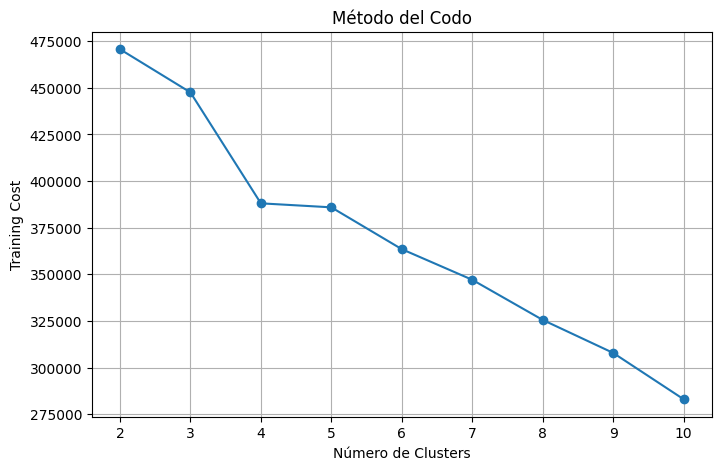

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

#grafico de codo
df_costos = pd.DataFrame(
    costos,
    columns=["K","Coste"])

plt.figure(figsize=(8,5))

plt.plot(
    df_costos["K"],
    df_costos["Coste"],
    marker="o")

plt.title("Método del Codo")
plt.xlabel("Número de Clusters")
plt.ylabel("Training Cost")

plt.grid(True)

plt.show()

In [40]:
from pyspark.ml.evaluation import ClusteringEvaluator

#mejor k con silhouette
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

resultados = []

for k in range(2,11):

    modelo = KMeans(
        k=k,
        seed=42,
        featuresCol="features_scaled").fit(train_df)

    pred = modelo.transform(test_df)

    evaluator = ClusteringEvaluator(
        featuresCol="features_scaled",
        predictionCol="prediction",
        metricName="silhouette")

    score = evaluator.evaluate(pred)

    resultados.append(
        (k, score))

for k, score in resultados:
    print(f"K={k} | Silhouette={score:.4f}")

K=2 | Silhouette=0.3160
K=3 | Silhouette=0.1563
K=4 | Silhouette=0.2214
K=5 | Silhouette=0.2208
K=6 | Silhouette=0.2182
K=7 | Silhouette=0.2297
K=8 | Silhouette=0.3026
K=9 | Silhouette=0.2633
K=10 | Silhouette=0.3050


In [41]:
k_optimo = 4

In [42]:
#modelo
modelo_final = KMeans(
    k=k_optimo,
    seed=42,
    featuresCol="features_scaled"
).fit(train_df)

In [43]:
#generar cluster
clusters = modelo_final.transform(df_final)

In [44]:
#distribucion
clusters.groupBy("prediction").count().orderBy("prediction").show()

+----------+-----+
|prediction|count|
+----------+-----+
|         0| 3823|
|         1|11803|
|         2| 5627|
|         3| 3951|
+----------+-----+



In [45]:
#silhoutte final
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="features_scaled",
    predictionCol="prediction")

silhouette = evaluator.evaluate(clusters)

print(
    f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.2121


In [46]:
#cluster
from pyspark.sql import functions as F

clusters.groupBy("prediction").agg(
    F.avg("Trip Miles").alias("Prom_Millas"),
    F.avg("Trip Seconds").alias("Prom_Segundos"),
    F.avg("Fare").alias("Prom_Fare"),
    F.avg("Tips").alias("Prom_Tips")
).orderBy("prediction").show(truncate=False)

+----------+------------------+------------------+------------------+-------------------+
|prediction|Prom_Millas       |Prom_Segundos     |Prom_Fare         |Prom_Tips          |
+----------+------------------+------------------+------------------+-------------------+
|0         |7.59383468480251  |1455.4582788386085|24.48897462725608 |0.12921527596128693|
|1         |2.1699745827332038|659.0932813691435 |10.811134457341355|1.1497602304498857 |
|2         |14.699905811267097|2452.1210236360407|42.96359161187133 |7.779486404833838  |
|3         |3.132313338395344 |827.440901037712  |13.362391799544422|2.613507972665148  |
+----------+------------------+------------------+------------------+-------------------+



### Resultados
* Metodo del codo: permitió identificar que K=4 era una cantidad adecuada de clusters para segmentar los viajes.
* Silhouette Score: el modelo obtuvo un valor de 0.2121. Lo que indica que existen diferencias entre los grupos encontrados, aunque algunos viajes presentan características similares entre sí, por lo que, podria evalauar cambiar el numero de cluster.
* Cluster 2: agrupa los viajes más largos y costosos, con mayores tarifas y propinas promedio.
* Cluster 1: contiene los viajes más cortos y de menor costo.
* Cluster 0: representa viajes de distancia media con propinas bajas.
* Cluster 3: agrupa viajes cortos con costos moderados y propinas superiores a las observadas en el Cluster 0.
* Las variables relacionadas con distancia, duración, tarifa y propina permitieron diferenciar los distintos perfiles de viaje.
* La muestra M' es solo el 15% de la muestra inicial M, por lo que trabajar con más registros podría generar clusters más representativos y diferenciados entre sí.
* Se pueden probar otros valores de K o algoritmos de agrupamiento para comparar resultados y obtener una segmentación más precisa.

### Referencias Bibliográficas
* Apache Spark. (2026). pyspark.ml. Machine Learning. https://spark.apache.org/docs/latest/ml-guide.html
* Kaggle. (2023). Taxi Trips - 2023 [Dataset]. https://www.kaggle.com/datasets/mexwell/taxi-trips-2023
* OpenAI. (2026). ChatGPT (basado en GPT-5.5)[Modelo de lenguaje grande], utilizado para generación y depuración de código y revisión de textos. https://chat.openai.com/
* Anthropic. (2026). Claude (basado en Sonnet 4.6 Adaptativo)[Modelo de lenguaje grande], utilizado para generación y depuración de código y revisión de textos. https://claude.ai/
* Ryza, S. et al. (2023). Advanced Analytics with PySpark. O'Reilly Media. https://learning.oreilly.com/library/view/advanced-analytics-with/9781098103644/
* Cuevas, E. (2025). Aprendizaje No Supervisado: Conceptos, Diferencias, Métodos, Aplicaciones y Perspectivas Futuras. MasScience. https://www.masscience.com/aprendizaje-no-supervisado-conceptos-diferencias-metodos-aplicaciones-y-perspectivas-futuras/